In [11]:

!pip install -q ranx

!git clone https://github.com/TalentCLEF/talentclef26_evaluation_script.git /kaggle/working/talentclef26_evaluation_script

fatal: destination path '/kaggle/working/talentclef26_evaluation_script' already exists and is not an empty directory.


In [12]:

import os, gc, math, random, warnings, subprocess
import glob
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import time

import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset

from pathlib import Path
from tqdm.auto import tqdm

from transformers import (
    AutoModel,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [13]:

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary device: {DEVICE}")

GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Primary device: cuda


In [14]:

MODEL_NAME = "jjzha/jobbert-base-cased"
OUTPUT_DIR = "/kaggle/working/jobbert_output"
LOGGING_DIR = "/kaggle/working/jobbert_logs"

TRAIN_CSV = (
    "/kaggle/input/datasets/danielantoniudumitru/"
    "clef-talentclef-subtaska/A/Training/"
    "normalization/job_applicant_dataset.csv"
)
DEV_BASE = "/kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en"
CORPUS_DIR = os.path.join(DEV_BASE, "corpus")
QUERY_DIR = os.path.join(DEV_BASE, "queries")
QRELS_FILE = os.path.join(DEV_BASE, "qrels.tsv")
EVAL_BASE = "/kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Testing/en"
CORPUS_EVAL = os.path.join(EVAL_BASE, "corpus")
QUERY_EVAL = os.path.join(EVAL_BASE, "queries")

MAX_LEN = 512
TRAIN_BATCH = 8
EVAL_BATCH = 8
GRAD_ACCUM = 4
NUM_EPOCHS = 4
LR = 1e-5
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01

PROJ_DIM = 512
TAU_INIT = 0.07
SKILL_WEIGHT = 0.25

HNM_TOPK = 50
HNM_NEGATIVES = 1
HNM_EPOCHS = 4
HNM_BATCH = 16
HNM_ROUNDS = 2

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

In [15]:

print("Loading training CSV …")
df_train = pd.read_csv(TRAIN_CSV)
print(f"Shape : {df_train.shape}")
print(df_train.head(3))
print("\nColumn dtypes:\n", df_train.dtypes)
print("\nValue counts (label):\n", df_train.iloc[:, -1].value_counts())

Loading training CSV …
Shape : (10000, 9)
  Job Applicant Name  Age  Gender             Race   Ethnicity  \
0       Daisuke Mori   29    Male  Mongoloid/Asian  Vietnamese   
1     Taichi Shimizu   31    Male  Mongoloid/Asian    Filipino   
2       Sarah Martin   46  Female  White/Caucasian       Dutch   

                                              Resume          Job Roles  \
0  Daisuke Mori\n243 Hill Street\nAmsterdam, Nort...      Fitness Coach   
1  Taichi Shimizu\n108 Market Street\nCape Town, ...          Physician   
2  Sarah Martin\n10 Lincoln Avenue\nMumbai, Mahar...  Financial Analyst   

                                     Job Description  Best Match  
0  Fitness Coach\n\nA Fitness Coach is responsibl...           0  
1  Physician\n\nDiagnose and treat illnesses, pre...           0  
2  Financial Analyst\n\nAs a Financial Analyst, y...           0  

Column dtypes:
 Job Applicant Name    object
Age                    int64
Gender                object
Race                

In [16]:

text_a_col = "Job Description"
text_b_col = "Resume"
label_col = "Best Match"

print(f"Text A: {text_a_col}")
print(f"Text B: {text_b_col}")
print(f"Label: {label_col}")

df_train[label_col] = df_train[label_col].astype(int)
assert set(df_train[label_col].unique()).issubset({0, 1}), \
    "Label column must contain only 0 and 1!"

Text A: Job Description
Text B: Resume
Label: Best Match


In [17]:

print(f"\nLoading tokenizer: {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Loading tokenizer: jjzha/jobbert-base-cased …


In [18]:

def read_text_file(folder, file_id):
    path = os.path.join(folder, str(file_id))
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read().strip()

def extract_skills(text):
    if not text:
        return set()
    t = text
    m = re.search(r"(?is)(?:^|\n)\s*(?:skills|required skills)\s*[:\-\n]+(.*?)(?:\n\s*\n|\n---|$)", t)
    block = None
    if m:
        block = m.group(1)
    else:
        lines = t.splitlines()
        for i, line in enumerate(lines):
            if re.search(r"(?i)^\s*(skills|required skills)\b", line):
                block = "\n".join(lines[i+1:i+7])
                break
    if not block:
        return set()

    parts = re.split(r"[\n,•\-\t]+", block)
    tokens = set()
    for p in parts:
        s = p.strip()
        if not s:
            continue
        s = re.sub(r"[^\w &/+-]+$", "", s)
        s = re.sub(r"^[^\w]+", "", s)
        s = s.lower()
        s = " ".join(s.split())
        if len(s) > 1:
            tokens.add(s)
    return tokens

In [19]:

print("\nLoading qrels …")
qrels = pd.read_csv(
    QRELS_FILE, sep="\t", header=None,
    names=["q_id", "iter", "c_id", "relevance"]
)
print(f"qrels shape: {qrels.shape}")
print(qrels.head())


Loading qrels …
qrels shape: (472, 4)
    q_id  iter   c_id  relevance
0  36044     0  13884          1
1  39060     0   9516          1
2  39060     0  12097          1
3  32447     0  13882          1
4  39060     0   6533          1


In [20]:

print("\nLoading all query files …")
query_dict = {}
query_skills = {}
for fpath in sorted(glob.glob(os.path.join(QUERY_DIR, "*"))):
    fid = os.path.basename(fpath)
    txt = read_text_file(QUERY_DIR, fid)
    query_dict[fid] = txt
    query_skills[fid] = extract_skills(txt)
print(f"  Queries found: {len(query_dict)}")

print("Loading all corpus files …")
corpus_dict = {}
corpus_skills = {}
for fpath in sorted(glob.glob(os.path.join(CORPUS_DIR, "*"))):
    fid = os.path.basename(fpath)
    txt = read_text_file(CORPUS_DIR, fid)
    corpus_dict[fid] = txt
    corpus_skills[fid] = extract_skills(txt)
print(f"  Corpus elements found: {len(corpus_dict)}")

positive_set = set(zip(
    qrels["q_id"].astype(str),
    qrels["c_id"].astype(str)
))

print("\nBuilding all (query × corpus) pairs …")
dev_records = []
for q_id, q_text in tqdm(query_dict.items(), desc="Queries"):
    for c_id, c_text in corpus_dict.items():
        dev_records.append({
            "q_id": q_id,
            "c_id": c_id,
            "query_text": q_text,
            "corpus_text": c_text,
            "relevance": 1 if (q_id, c_id) in positive_set else 0,
        })

df_dev = pd.DataFrame(dev_records)

corpus_ids_list = list(corpus_dict.keys())
random.seed(SEED)

dev_triplets = []
for _, row in qrels.iterrows():
    q_id = str(row["q_id"])
    c_id = str(row["c_id"])
    q_text = query_dict.get(q_id, "")
    p_text = corpus_dict.get(c_id, "")

    neg_candidates = [cid for cid in corpus_ids_list if cid != c_id]
    neg_c_id = random.choice(neg_candidates)
    n_text = corpus_dict.get(neg_c_id, "")

    dev_triplets.append({
        "query": q_text,
        "positive": p_text,
        "negative": n_text
    })

df_dev_triplets = pd.DataFrame(dev_triplets)

print(f"Positives: {(df_dev['relevance']==1).sum()}")
print(f"Negatives: {(df_dev['relevance']==0).sum()}")


Loading all query files …
  Queries found: 10
Loading all corpus files …
  Corpus elements found: 472

Building all (query × corpus) pairs …


Queries:   0%|          | 0/10 [00:00<?, ?it/s]

Positives: 472
Negatives: 4248


In [21]:

class SingleTextDataset(Dataset):
    def __init__(self, texts, ids, tokenizer, max_len):
        self.texts = texts
        self.ids = ids
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            " ".join(str(self.texts[idx]).split()[:384]),
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_token_type_ids=False,
        )
        return enc


def mean_pooling(model_output, attention_mask):
    token_emb  = model_output.last_hidden_state
    mask_exp   = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
    return torch.sum(token_emb * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)


class TripletDataset(Dataset):
    def __init__(self, df, tokenizer, max_len,
                 q_col, pos_col, neg_col):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.q_col = q_col
        self.pos_col = pos_col
        self.neg_col = neg_col
        self.data = df.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def _enc(self, text):
        tokens = self.tokenizer(
            str(text),
            max_length=None,
            truncation=False,
            padding=False,
            return_tensors=None
        )
        input_ids = tokens["input_ids"]
        attn_mask = tokens["attention_mask"]
    
        stride = 384
        max_chunk = 512
        chunks_ids, chunks_mask = [], []
    
        for start in range(0, max(1, len(input_ids)), stride):
            end  = start + max_chunk
            cids = input_ids[start:end]
            cmsk = attn_mask[start:end]
            pad_len = max_chunk - len(cids)
            cids  = cids  + [self.tokenizer.pad_token_id] * pad_len
            cmsk  = cmsk  + [0] * pad_len
            chunks_ids.append(cids)
            chunks_mask.append(cmsk)
            if end >= len(input_ids):
                break

        return {
            "input_ids": torch.tensor(chunks_ids,  dtype=torch.long),
            "attention_mask": torch.tensor(chunks_mask, dtype=torch.long)
        }

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        q_enc = self._enc(row[self.q_col])
        p_enc = self._enc(row[self.pos_col])
        n_enc = self._enc(row[self.neg_col])
        return {
            "q_input_ids": q_enc["input_ids"],
            "q_attention_mask": q_enc["attention_mask"],
            "p_input_ids": p_enc["input_ids"],
            "p_attention_mask": p_enc["attention_mask"],
            "n_input_ids": n_enc["input_ids"],
            "n_attention_mask": n_enc["attention_mask"]
        }


def triplet_collate_fn(batch):
    def pad_chunks(tensors):
        max_chunks = max(t.size(0) for t in tensors)
        padded = []

        for t in tensors:
            pad = torch.zeros(max_chunks - t.size(0), t.size(1), dtype=t.dtype)
            padded.append(torch.cat([t, pad], dim=0))

        return torch.stack(padded) 

    return {
        "q_input_ids": pad_chunks([b["q_input_ids"] for b in batch]),
        "q_attention_mask": pad_chunks([b["q_attention_mask"] for b in batch]),
        "p_input_ids": pad_chunks([b["p_input_ids"] for b in batch]),
        "p_attention_mask": pad_chunks([b["p_attention_mask"] for b in batch]),
        "n_input_ids": pad_chunks([b["n_input_ids"] for b in batch]),
        "n_attention_mask": pad_chunks([b["n_attention_mask"] for b in batch])
    }

dev_val_dataset = TripletDataset(
    df_dev_triplets, tokenizer, MAX_LEN,
    "query", "positive", "negative"
)

print(f"Dev triplets for validation: {len(df_dev_triplets)}")

Dev triplets for validation: 472


In [22]:

NUM_CROSS_ROLE_NEGS = 1

positives = df_train[df_train[label_col] == 1].reset_index(drop=True)
negatives = df_train[df_train[label_col] == 0].reset_index(drop=True)

random.seed(SEED)

neg_by_role = {}
for _, row in negatives.iterrows():
    role = str(row.get("Job Roles", "unknown"))
    neg_by_role.setdefault(role, []).append(row[text_b_col])

all_neg_texts = negatives[text_b_col].tolist()
all_roles = list(neg_by_role.keys())

triplets = []
for _, row in positives.iterrows():
    query_role = str(row.get("Job Roles", "unknown"))

    other_roles = [r for r in all_roles if r != query_role]
    if other_roles:
        neg_role = random.choice(other_roles)
        neg_pool = neg_by_role[neg_role]
    else:
        neg_pool = all_neg_texts

    neg_text = random.choice(neg_pool)
    triplets.append({
        "query"   : row[text_a_col],
        "positive": row[text_b_col],
        "negative": neg_text
    })

df_triplets = pd.DataFrame(triplets)

print(f"Triplet train : {len(df_triplets)}  ← all CSV triplets")
print(f"Triplet val   : {len(df_dev_triplets)}  ← from development set")

train_dataset = TripletDataset(df_triplets, tokenizer, MAX_LEN,
                                "query", "positive", "negative")
val_dataset = dev_val_dataset
data_collator = triplet_collate_fn

Triplet train : 4850  ← all CSV triplets
Triplet val   : 472  ← from development set


In [23]:

class BiEncoder(nn.Module):
    def __init__(self, model_name, proj_dim=256, tau_init=0.05, dropout_p=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.embed_dim = self.encoder.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(self.embed_dim, proj_dim),
            nn.Dropout(dropout_p),
            nn.LayerNorm(proj_dim)
        )
        self.tau = nn.Parameter(torch.tensor(tau_init))

    def encode(self, input_ids, attention_mask):
        B, num_chunks, seq_len = input_ids.size()

        ids_flat = input_ids.view(B * num_chunks, seq_len)
        mask_flat = attention_mask.view(B * num_chunks, seq_len)

        out = self.encoder(input_ids=ids_flat, attention_mask=mask_flat)
        emb_flat = mean_pooling(out, mask_flat)
        emb_flat = emb_flat.view(B, num_chunks, -1)

        decay_rate = 0.7
        num_c = emb_flat.size(1)
        weights = torch.tensor([decay_rate ** i for i in range(num_c)], dtype=emb_flat.dtype, device=emb_flat.device).unsqueeze(0).unsqueeze(-1)

        chunk_mask = attention_mask.sum(dim=-1).gt(0).float()
        chunk_mask_exp = chunk_mask.unsqueeze(-1)

        weighted = emb_flat * weights * chunk_mask_exp
        weight_sum = (weights * chunk_mask_exp).sum(dim=1)
        emb = weighted.sum(dim=1) / weight_sum.clamp(min=1e-9)

        emb = self.proj(emb)

        return F.normalize(emb, p=2, dim=-1)

    def get_temp(self):
        return F.softplus(self.tau)

    def forward(self, q_input_ids, q_attention_mask,
                p_input_ids, p_attention_mask,
                n_input_ids, n_attention_mask):
        q_emb = self.encode(q_input_ids, q_attention_mask)
        p_emb = self.encode(p_input_ids, p_attention_mask)
        n_emb = self.encode(n_input_ids, n_attention_mask)
        return q_emb, p_emb, n_emb

model = BiEncoder(MODEL_NAME, proj_dim=PROJ_DIM, tau_init=TAU_INIT).to(DEVICE)
if NUM_GPUS > 1:
    model = nn.DataParallel(model)

_m = model.module if hasattr(model, "module") else model
print(f"Bi-encoder parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Temperature           : {_m.get_temp().item():.4f}")

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Bi-encoder parameters : 108,705,025
Temperature           : 0.7288


In [24]:

def compute_metrics(eval_pred):
    return {}

In [25]:

steps_per_epoch = math.ceil(len(train_dataset) / (TRAIN_BATCH * max(NUM_GPUS, 1) * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

os.environ["TENSORBOARD_LOGGING_DIR"] = LOGGING_DIR

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    logging_dir = LOGGING_DIR,

    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size = EVAL_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,

    learning_rate = LR,
    weight_decay = WEIGHT_DECAY,
    warmup_steps = warmup_steps,
    lr_scheduler_type = "cosine",
    max_grad_norm = 1.0,

    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False,
    remove_unused_columns = False,
    dataloader_num_workers = 0, 

    report_to = "none",

    fp16 = True,
    seed = SEED,

    disable_tqdm = False
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [26]:

class TripletTrainer(Trainer):
    def _remove_unused_columns(self, dataset, description=None):
        return dataset

    def create_optimizer(self):
        _model = self.model.module if hasattr(self.model, "module") else self.model
        encoder = _model.encoder
        proj = _model.proj
        no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}

        base_lr = self.args.learning_rate
        decay_factor = 0.9
        num_layers = encoder.config.num_hidden_layers

        param_groups = []

        proj_lr = base_lr * 8
        for name, param in proj.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": proj_lr,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01,
            })

        for layer_idx in range(num_layers - 1, -1, -1):
            layer_lr = base_lr * (decay_factor ** (num_layers - 1 - layer_idx))
            for name, param in encoder.encoder.layer[layer_idx].named_parameters():
                param_groups.append({
                    "params": [param],
                    "lr": layer_lr,
                    "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01,
                })

        embed_lr = base_lr * (decay_factor ** num_layers)
        for name, param in encoder.embeddings.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": embed_lr,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01,
            })

        self.optimizer = AdamW(param_groups)
        return self.optimizer

    def prediction_step(self, model, inputs, prediction_loss_only,
                        ignore_keys=None):
        model.eval()
        with torch.no_grad():
            result = self.compute_loss(model, inputs, return_outputs=True)
            loss   = result[0]
        return (loss.detach(), None, None)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        _model = model.module if hasattr(model, "module") else model

        q_emb, p_emb, n_emb = model(
            q_input_ids = inputs["q_input_ids"],
            q_attention_mask = inputs["q_attention_mask"],
            p_input_ids = inputs["p_input_ids"],
            p_attention_mask = inputs["p_attention_mask"],
            n_input_ids = inputs["n_input_ids"],
            n_attention_mask = inputs["n_attention_mask"]
        )

        tau = _model.get_temp()
        B = q_emb.size(0)
        labels = torch.arange(B).to(q_emb.device)

        sim_matrix = torch.mm(q_emb, p_emb.T) / tau

        ce_loss = F.cross_entropy(sim_matrix, labels, label_smoothing=0.05)
        margin_loss = F.triplet_margin_loss(q_emb, p_emb, n_emb, margin=0.2, p=2)
        loss = ce_loss + 0.5 * margin_loss

        return (loss, (q_emb, p_emb, n_emb)) if return_outputs else loss


trainer = TripletTrainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    data_collator = triplet_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
)

In [27]:

print("\n" + "="*60)
print("  Starting JobBERT fine-tuning …")
print("="*60)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nTraining summary:")
print(train_result.metrics)



  Starting JobBERT fine-tuning …


Epoch,Training Loss,Validation Loss
1,No log,2.252910
2,No log,2.226274
3,No log,2.221722
4,No log,2.220620



Training summary:
{'train_runtime': 1558.9244, 'train_samples_per_second': 12.444, 'train_steps_per_second': 0.195, 'total_flos': 0.0, 'train_loss': 2.021505255448191, 'epoch': 4.0}


In [28]:

def encode_texts(text_dict, tokenizer, model, max_len, batch_size=16, desc="Encoding"):
    ids = list(text_dict.keys())
    texts = list(text_dict.values())
    all_embs = []

    _model = model.module if hasattr(model, "module") else model
    _model.eval()

    def enc_text(text):
        tokens = tokenizer(
            str(text),
            max_length=None,
            truncation=False,
            padding=False,
            return_tensors=None
        )

        input_ids = tokens["input_ids"]
        attn_mask = tokens["attention_mask"]
        stride, max_chunk = 384, 512
        chunks_ids, chunks_mask = [], []

        for start in range(0, max(1, len(input_ids)), stride):
            end = start + max_chunk
            cids = input_ids[start:end]
            cmsk = attn_mask[start:end]
            pad_len = max_chunk - len(cids)
            chunks_ids.append(cids  + [tokenizer.pad_token_id] * pad_len)
            chunks_mask.append(cmsk + [0] * pad_len)
            if end >= len(input_ids):
                break
        return (torch.tensor(chunks_ids,  dtype=torch.long),
                torch.tensor(chunks_mask, dtype=torch.long))

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=desc):
            batch_texts = texts[i:i+batch_size]
            enc_list    = [enc_text(t) for t in batch_texts]

            max_chunks = max(e[0].size(0) for e in enc_list)
            ids_batch, mask_batch = [], []
            for eids, emsk in enc_list:
                pad = torch.zeros(max_chunks - eids.size(0), 512, dtype=torch.long)
                ids_batch.append(torch.cat([eids, pad], dim=0))
                mask_batch.append(torch.cat([emsk, pad], dim=0))

            ids_t  = torch.stack(ids_batch).to(DEVICE)
            mask_t = torch.stack(mask_batch).to(DEVICE)

            embs = _model.encode(ids_t, mask_t)           
            all_embs.append(embs.cpu().numpy())

    return {id_: emb for id_, emb in zip(ids, np.vstack(all_embs))}

print("\nEncoding queries …")
query_embeddings  = encode_texts(query_dict,  tokenizer, model, MAX_LEN, desc="Queries")
print("Encoding corpus …")
corpus_embeddings = encode_texts(corpus_dict, tokenizer, model, MAX_LEN, desc="Corpus")

print("\nLoading test query files …")
test_query_dict = {}
for fpath in sorted(glob.glob(os.path.join(QUERY_EVAL, "*"))):
    fid = os.path.basename(fpath)
    test_query_dict[fid] = read_text_file(QUERY_EVAL, fid)
print(f"  Test queries : {len(test_query_dict)}")

print("Loading test corpus files …")
test_corpus_dict = {}
for fpath in sorted(glob.glob(os.path.join(CORPUS_EVAL, "*"))):
    fid = os.path.basename(fpath)
    test_corpus_dict[fid] = read_text_file(CORPUS_EVAL, fid)
print(f"  Test corpus  : {len(test_corpus_dict)}")

print("\nEncoding test queries …")
test_query_embeddings  = encode_texts(test_query_dict,  tokenizer, model,
                                       MAX_LEN, desc="Test Queries")
print("Encoding test corpus …")
test_corpus_embeddings = encode_texts(test_corpus_dict, tokenizer, model,
                                       MAX_LEN, desc="Test Corpus")


Encoding queries …


Queries:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding corpus …


Corpus:   0%|          | 0/30 [00:00<?, ?it/s]


Loading test query files …
  Test queries : 40
Loading test corpus files …
  Test corpus  : 476

Encoding test queries …


Test Queries:   0%|          | 0/3 [00:00<?, ?it/s]

Encoding test corpus …


Test Corpus:   0%|          | 0/30 [00:00<?, ?it/s]

In [30]:

def iterative_hard_negative_mining(model, tokenizer, df_trip_train, corpus_dict, query_dict,
                                   rounds=2, topk=50, negatives_per_pos=1, epochs=3, batch_size=16,
                                   out_dir=OUTPUT_DIR):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    p_ids = list(corpus_dict.keys())
    p_texts = list(corpus_dict.values())

    for r in range(rounds):
        print(f"\nHNM Round {r+1}/{rounds}")

        unique_q = df_trip_train['query'].unique().tolist()
        q_dict = {str(i): t for i, t in enumerate(unique_q)}
        p_dict = {str(i): t for i, t in enumerate(p_texts)}

        print("Encoding queries for HNM ...")
        q_embs = encode_texts(q_dict, tokenizer, model, MAX_LEN, batch_size=batch_size, desc=f"HNM-Q-R{r+1}")
        print("Encoding corpus for HNM ...")
        p_embs = encode_texts(p_dict, tokenizer, model, MAX_LEN, batch_size=batch_size, desc=f"HNM-P-R{r+1}")

        Q = np.stack([q_embs[k] for k in q_dict.keys()])
        P = np.stack([p_embs[k] for k in p_dict.keys()])
        sim = Q @ P.T

        p_texts_ordered = [p_dict[k] for k in p_dict.keys()]

        pos_per_q = {}
        for _, row in df_trip_train.iterrows():
            pos_per_q.setdefault(row['query'], set()).add(row['positive'])

        q2idx = {q:i for i,q in enumerate(unique_q)}
        hard_triplets = []
        for _, row in df_trip_train.iterrows():
            qtext = row['query']
            ptext = row['positive']
            qi = q2idx[qtext]
            sims = sim[qi]
            top_idxs = np.argsort(-sims)[:topk]
            selected_negs = []

            for idx in top_idxs:
                cand = p_texts_ordered[idx]
                if cand == ptext or cand in pos_per_q.get(qtext, set()):
                    continue
                selected_negs.append(cand)
                if len(selected_negs) >= negatives_per_pos:
                    break

            if not selected_negs:
                choices = [p_texts_ordered[idx] for idx in top_idxs if p_texts_ordered[idx] != ptext]
                if choices:
                    selected_negs = [random.choice(choices)]
                else:
                    selected_negs = [random.choice([t for t in p_texts if t != ptext])]

            for neg in selected_negs:
                hard_triplets.append({'query': qtext, 'positive': ptext, 'negative': neg})

        df_hard = pd.DataFrame(hard_triplets)
        print(f"Round {r+1}: mined {len(df_hard)} hard triplets")

        round_out = os.path.join(out_dir, f"hnm_round{r+1}")
        os.makedirs(round_out, exist_ok=True)
        hnm_args = TrainingArguments(
            output_dir = round_out,
            logging_dir = os.path.join(LOGGING_DIR, f"hnm_round{r+1}"),
            num_train_epochs = epochs,
            per_device_train_batch_size = TRAIN_BATCH,
            per_device_eval_batch_size = EVAL_BATCH,
            gradient_accumulation_steps = GRAD_ACCUM,
            learning_rate = LR,
            weight_decay = WEIGHT_DECAY,
            warmup_steps = warmup_steps,
            lr_scheduler_type = "cosine",
            eval_strategy = "epoch",
            save_strategy = "epoch",
            load_best_model_at_end = True,
            metric_for_best_model = "eval_loss",
            greater_is_better = False,
            remove_unused_columns = False,
            dataloader_num_workers = 0,
            report_to = "none",
            fp16 = True,
            seed = SEED,
            disable_tqdm = False
        )

        train_dataset = TripletDataset(df_hard, tokenizer, MAX_LEN, "query", "positive", "negative")
        trainer = TripletTrainer(
            model = model,
            args = hnm_args,
            train_dataset = train_dataset,
            eval_dataset = val_dataset,
            data_collator = triplet_collate_fn,
            compute_metrics = compute_metrics,
            callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
        )
        print("Starting HNM fine-tuning round ...")
        train_result = trainer.train()
        trainer.save_model(round_out)
        tokenizer.save_pretrained(round_out)

        model = trainer.model
        model.to(DEVICE)

    return model, tokenizer


print("\nRunning improved iterative HNM pipeline...")
model, tokenizer = iterative_hard_negative_mining(
    model = model,
    tokenizer = tokenizer,
    df_trip_train = df_triplets,
    corpus_dict = corpus_dict,
    query_dict = query_dict,
    rounds = HNM_ROUNDS,
    topk = HNM_TOPK,
    negatives_per_pos = HNM_NEGATIVES,
    epochs = HNM_EPOCHS,
    batch_size = HNM_BATCH,
    out_dir = OUTPUT_DIR
)

print("Re-encoding dev queries and corpus with updated model …")
query_embeddings  = encode_texts(query_dict,  tokenizer, model,
                                  MAX_LEN, desc="Dev Queries-after-HNM")
corpus_embeddings = encode_texts(corpus_dict, tokenizer, model,
                                  MAX_LEN, desc="Dev Corpus-after-HNM")

print("Re-encoding test queries and corpus with updated model …")
test_query_embeddings  = encode_texts(test_query_dict,  tokenizer, model,
                                       MAX_LEN, desc="Test Queries-after-HNM")
test_corpus_embeddings = encode_texts(test_corpus_dict, tokenizer, model,
                                       MAX_LEN, desc="Test Corpus-after-HNM")


Running improved iterative HNM pipeline...

HNM Round 1/2
Encoding queries for HNM ...


HNM-Q-R1:   0%|          | 0/303 [00:00<?, ?it/s]

Encoding corpus for HNM ...


HNM-P-R1:   0%|          | 0/30 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Dev Queries-after-HNM:   0%|          | 0/1 [00:00<?, ?it/s]

Dev Corpus-after-HNM:   0%|          | 0/30 [00:00<?, ?it/s]

Re-encoding test queries and corpus with updated model …


Test Queries-after-HNM:   0%|          | 0/3 [00:00<?, ?it/s]

Test Corpus-after-HNM:   0%|          | 0/30 [00:00<?, ?it/s]

In [31]:

print("\nScoring all test query × corpus pairs …")

tq_ids = list(test_query_embeddings.keys())
tc_ids = list(test_corpus_embeddings.keys())

TQ = np.stack([test_query_embeddings[q] for q in tq_ids])
TC = np.stack([test_corpus_embeddings[c] for c in tc_ids])

test_sim_matrix = TQ @ TC.T
test_sim_norm   = (test_sim_matrix + 1.0) / 2.0

tq_skill_sets = [extract_skills(test_query_dict[q])  for q in tq_ids]
tc_skill_sets = [extract_skills(test_corpus_dict[c]) for c in tc_ids]

test_skill_overlap = np.zeros((len(tq_skill_sets), len(tc_skill_sets)), dtype=float)
for i, qset in enumerate(tq_skill_sets):
    for j, cset in enumerate(tc_skill_sets):
        union = qset | cset
        test_skill_overlap[i, j] = len(qset & cset) / len(union) if union else 0.0

test_final_sim = test_sim_norm + SKILL_WEIGHT * test_skill_overlap

test_records = []
for i, q_id in enumerate(tq_ids):
    for j, c_id in enumerate(tc_ids):
        test_records.append({
            "q_id"     : q_id,
            "c_id"     : c_id,
            "pred_prob": float(test_final_sim[i, j]),
        })

df_test = pd.DataFrame(test_records)
print(f"Test scored pairs   : {len(df_test)}")
print(f"Unique test queries : {df_test['q_id'].nunique()}")
print(f"Unique test corpus  : {df_test['c_id'].nunique()}")


Scoring all test query × corpus pairs …
Test scored pairs   : 19040
Unique test queries : 40
Unique test corpus  : 476


In [32]:

RUN_TAG = "jobbert_run"
RUN_PATH = "/kaggle/working/run_en-en_jobbert.trec"

print("Generating TREC run file …")

run_rows = []
for q_id, grp in df_test.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank_idx, row in grp_sorted.iterrows():
        run_rows.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": int(grp_sorted.index.get_loc(rank_idx)) + 1,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })

df_run = pd.DataFrame(run_rows)

df_run = []
for q_id, grp in df_test.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(grp_sorted.iterrows(), start=1):
        df_run.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": rank,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })
df_run = pd.DataFrame(df_run)

with open(RUN_PATH, "w") as f:
    for _, row in df_run.iterrows():
        f.write(f"{row['q_id']} {row['Q0']} {row['doc_id']} "
                f"{row['rank']} {row['score']:.10f} {row['tag']}\n")

print(f"Run file saved: {RUN_PATH}")
print(f"  Total lines  : {len(df_run)}")
print(f"  Unique queries: {df_run['q_id'].nunique()} <- test set queries")
print(df_run.head(5).to_string(index=False))

Generating TREC run file …
Run file saved: /kaggle/working/run_en-en_jobbert.trec
  Total lines  : 19040
  Unique queries: 40 <- test set queries
q_id Q0 doc_id  rank    score         tag
1007 Q0  10401     1 0.927603 jobbert_run
1007 Q0  10758     2 0.919636 jobbert_run
1007 Q0  18703     3 0.902571 jobbert_run
1007 Q0  19158     4 0.895225 jobbert_run
1007 Q0  13263     5 0.882126 jobbert_run


In [33]:

import ranx

qrels_file = QRELS_FILE
run_file = RUN_PATH

print("Running official TalentCLEF 2026 evaluation …")
print(f"  qrels : {qrels_file}")
print(f"  run   : {run_file}")

command = [
    "python",
    "/kaggle/working/talentclef26_evaluation_script/talentclef_evaluate.py",
    "--task", "A",
    "--lang-mode", "en",
    "--qrels", qrels_file,
    "--run", run_file
]

result = subprocess.run(command, capture_output=True, text=True)

print("\n" + "="*60)
print("  Official Evaluation Results")
print("="*60)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

Running official TalentCLEF 2026 evaluation …
  qrels : /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  run   : /kaggle/working/run_en-en_jobbert.trec

  Official Evaluation Results
TalentCLEF 2026 - Task A Evaluation
Received parameters:
  Task: A
  Qrels: /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  Run: /kaggle/working/run_en-en_jobbert.trec
  Language Mode: en

Loading qrels...
Loading run...

Running Task A evaluation...

STDERR:
Traceback (most recent call last):
  File "/kaggle/working/talentclef26_evaluation_script/talentclef_evaluate.py", line 284, in <module>
    main()
  File "/kaggle/working/talentclef26_evaluation_script/talentclef_evaluate.py", line 258, in main
    results = evaluate_task_a(qrels, run, gender_filter=gender_filter)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/talentclef26_evaluation_script/talentclef_eval

In [34]:

def mean_average_precision(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    aps = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        if rel.sum() == 0:
            continue
        hits, ap = 0, 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                hits += 1
                ap += hits / rank
        aps.append(ap / rel.sum())
    return np.mean(aps) if aps else 0.0


def mean_reciprocal_rank(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    rrs = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        rr = 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    return np.mean(rrs) if rrs else 0.0


def precision_at_k(df, k, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    pk_list = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).head(k)
        pk_list.append(grp_sorted[rel_col].mean())
    return np.mean(pk_list) if pk_list else 0.0

In [35]:

df_dev.to_csv("/kaggle/working/jobbert_dev_predictions.csv", index=False)
print("\nPredictions saved to /kaggle/working/jobbert_dev_predictions.csv")


Predictions saved to /kaggle/working/jobbert_dev_predictions.csv


In [37]:

log_history = trainer.state.log_history

train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [e for e in log_history if "eval_loss" in e]

eval_epochs = [e["epoch"] for e in eval_logs]
eval_loss = [e["eval_loss"] for e in eval_logs]

train_epochs_raw = [e["epoch"] for e in train_logs]
train_loss_raw   = [e["loss"]  for e in train_logs]

train_loss_per_epoch = []
for ep in eval_epochs:
    lo = ep - 1.0
    vals = [train_loss_raw[i] for i, e in enumerate(train_epochs_raw) if lo < e <= ep]
    train_loss_per_epoch.append(np.mean(vals) if vals else float("nan"))

print(f"Epochs recorded: {eval_epochs}")
print(f"Train loss per epoch: {[round(v,4) for v in train_loss_per_epoch]}")
print(f"Eval  loss per epoch: {[round(v,4) for v in eval_loss]}")

Epochs recorded: [1.0, 2.0, 3.0, 4.0]
Train loss per epoch: [nan, nan, nan, nan]
Eval  loss per epoch: [2.2529, 2.2263, 2.2217, 2.2206]


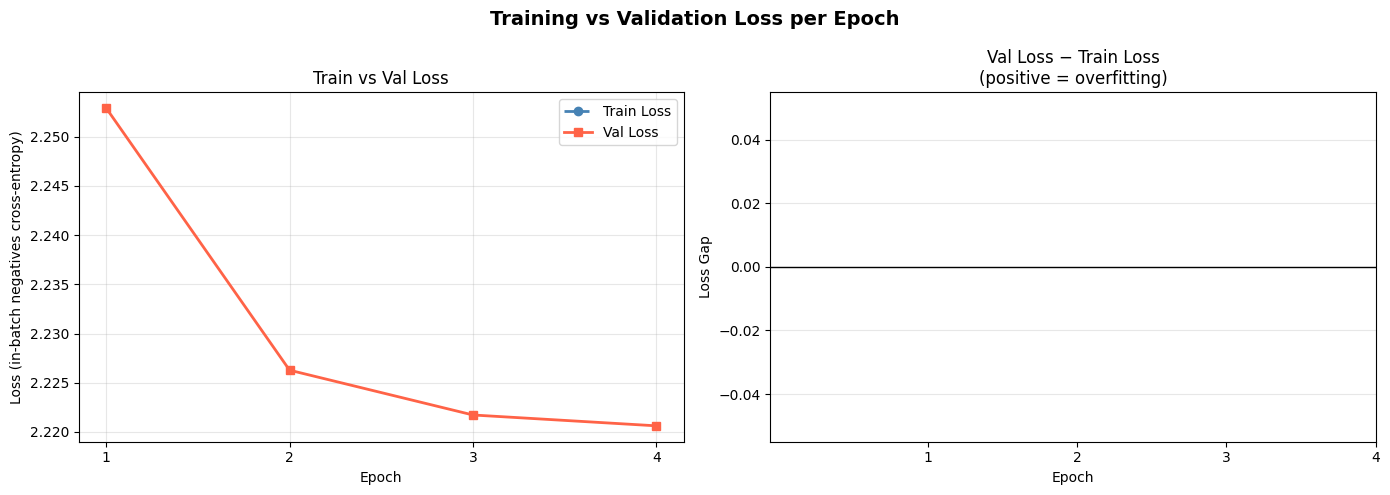

Saved: loss_per_epoch.png


In [38]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training vs Validation Loss per Epoch", fontsize=14, fontweight="bold")

axes[0].plot(eval_epochs, train_loss_per_epoch, marker="o", linestyle="--",
             color="steelblue", linewidth=2, label="Train Loss")
axes[0].plot(eval_epochs, eval_loss, marker="s", linestyle="-",
             color="tomato", linewidth=2, label="Val Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (in-batch negatives cross-entropy)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(eval_epochs)

gap = [e - t if not np.isnan(t) else float("nan")
       for e, t in zip(eval_loss, train_loss_per_epoch)]
axes[1].bar(eval_epochs, gap,
            color=["tomato" if g > 0 else "steelblue" for g in gap],
            alpha=0.8, edgecolor="black", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Val Loss − Train Loss\n(positive = overfitting)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Gap")
axes[1].set_xticks(eval_epochs)
axes[1].grid(True, alpha=0.3, axis="y")
for ep, g in zip(eval_epochs, gap):
    if not np.isnan(g):
        axes[1].text(ep, g + (0.001 if g >= 0 else -0.003),
                     f"{g:+.4f}", ha="center",
                     va="bottom" if g >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_per_epoch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_per_epoch.png")